# Credit Card Fraud Detection dengan XGBoost

Project ini membangun model klasifikasi untuk mendeteksi transaksi fraud pada
dataset Credit Card Fraud Detection. Target yang dipakai adalah `Class`:

- `0`: transaksi normal
- `1`: transaksi fraud

Karena kelas fraud sangat sedikit, evaluasi difokuskan pada precision, recall,
F1-score, ROC-AUC, dan terutama PR-AUC. Accuracy tidak dijadikan metrik utama.



## 0. Setup library

Jalankan cell instalasi di bawah ini hanya jika library belum tersedia,
terutama saat memakai Google Colab.



In [1]:
# Jika dibutuhkan di Google Colab, hilangkan tanda komentar pada baris berikut:
# !pip install xgboost imbalanced-learn shap

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42



## 1. Load dan pahami dataset

Dataset diasumsikan berada di `data/creditcard.csv`. Jika dijalankan di Colab,
unggah file `creditcard.csv` lalu sesuaikan `DATA_PATH` bila perlu.



In [2]:
DATA_PATH = Path("data/creditcard.csv")

if not DATA_PATH.exists():
    colab_path = Path("/content/creditcard.csv")
    if colab_path.exists():
        DATA_PATH = colab_path
    else:
        raise FileNotFoundError(
            "File dataset tidak ditemukan. Letakkan file CSV di "
            "`data/creditcard.csv` atau unggah `creditcard.csv` ke Colab."
        )

df = pd.read_csv(DATA_PATH)

print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())
print("\nTipe data:")
print(df.dtypes)

df.head()



Ukuran dataset: (284807, 31)

Nama kolom:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Tipe data:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Interpretasi:** kolom `V1` sampai `V28` adalah fitur numerik hasil transformasi
PCA. Kolom `Time` menunjukkan selisih waktu transaksi dari transaksi pertama
pada dataset, sedangkan `Amount` menunjukkan nilai transaksi. Kolom `Class`
adalah target klasifikasi.



In [3]:
class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100
imbalance_summary = pd.DataFrame(
    {
        "class_label": ["Normal (0)", "Fraud (1)"],
        "count": class_counts.values,
        "percentage": class_percent.values,
    },
    index=class_counts.index,
)

display(imbalance_summary)

normal_count = class_counts.loc[0]
fraud_count = class_counts.loc[1]
imbalance_ratio = normal_count / fraud_count

print(f"Jumlah transaksi normal: {normal_count:,}")
print(f"Jumlah transaksi fraud : {fraud_count:,}")
print(f"Persentase normal      : {class_percent.loc[0]:.4f}%")
print(f"Persentase fraud       : {class_percent.loc[1]:.4f}%")
print(f"Rasio normal:fraud     : {imbalance_ratio:.2f}:1")



,class_label,count,percentage
Class,,,
0,Normal (0),284315,99.827251
1,Fraud (1),492,0.172749


Jumlah transaksi normal: 284,315
Jumlah transaksi fraud : 492
Persentase normal      : 99.8273%
Persentase fraud       : 0.1727%
Rasio normal:fraud     : 577.88:1


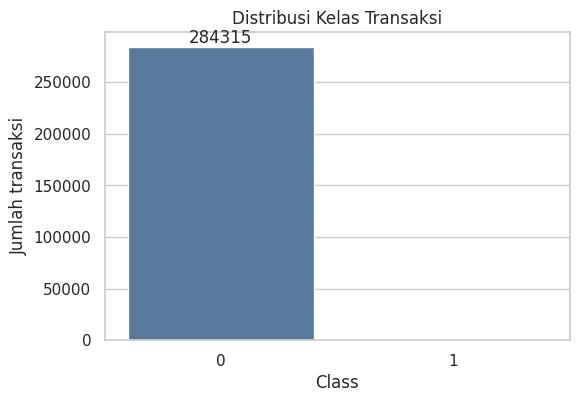

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=class_counts.index.astype(str),
    y=class_counts.values,
    palette=["#4C78A8", "#F58518"],
)
ax.set_title("Distribusi Kelas Transaksi")
ax.set_xlabel("Class")
ax.set_ylabel("Jumlah transaksi")
ax.bar_label(ax.containers[0], fmt="%d")
plt.show()



**Interpretasi:** kelas fraud hanya sebagian sangat kecil dari dataset. Model
yang hanya menebak "normal" hampir selalu benar secara accuracy, tetapi gagal
untuk tujuan deteksi fraud.



## 2. Exploratory Data Analysis

Bagian ini mengecek missing value, duplikasi, statistik deskriptif, distribusi
`Amount` dan `Time`, serta korelasi fitur terhadap target.



In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print("Total missing value:", int(missing_values.sum()))
display(missing_values[missing_values > 0])
print("Jumlah baris duplikat:", int(duplicate_count))



Total missing value: 0


Series([], dtype: int64)

Jumlah baris duplikat: 1081


In [6]:
df.describe().T



,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**Interpretasi:** tidak ada missing value pada dataset ini. Baris duplikat
terdeteksi; untuk baseline yang umum pada dataset Credit Card Fraud Detection,
baris tersebut tidak langsung dihapus agar hasil tetap sebanding dengan banyak
referensi. Jika tujuan production, duplikasi perlu ditelusuri sebagai aturan
bisnis terpisah.



In [7]:
amount_by_class = df.groupby("Class")["Amount"].describe()
time_by_class = df.groupby("Class")["Time"].describe()

print("Statistik Amount per kelas:")
display(amount_by_class)

print("Statistik Time per kelas:")
display(time_by_class)



Statistik Amount per kelas:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Statistik Time per kelas:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


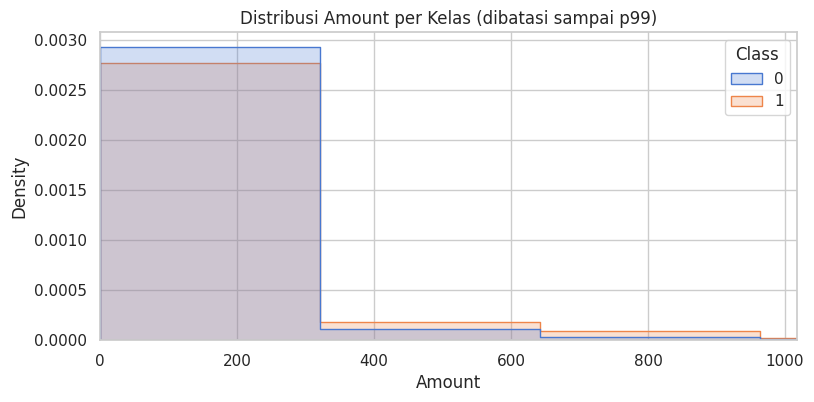

In [8]:
plt.figure(figsize=(9, 4))
sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=80,
    stat="density",
    common_norm=False,
    element="step",
)
plt.xlim(0, df["Amount"].quantile(0.99))
plt.title("Distribusi Amount per Kelas (dibatasi sampai p99)")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()



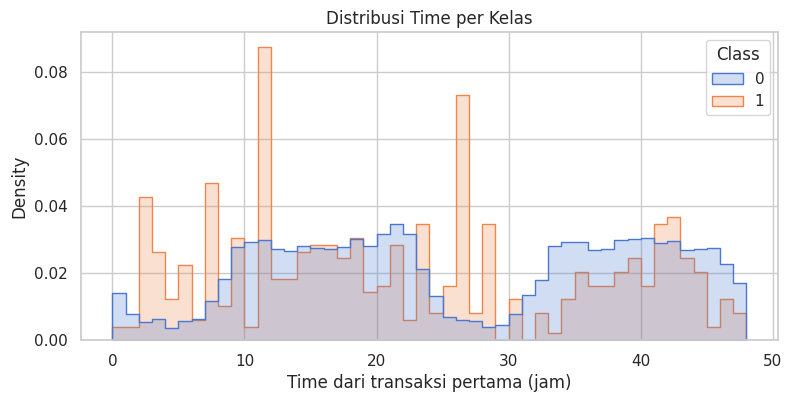

In [9]:
plot_df = df.assign(Time_hours=df["Time"] / 3600)

plt.figure(figsize=(9, 4))
sns.histplot(
    data=plot_df,
    x="Time_hours",
    hue="Class",
    bins=48,
    stat="density",
    common_norm=False,
    element="step",
)
plt.title("Distribusi Time per Kelas")
plt.xlabel("Time dari transaksi pertama (jam)")
plt.ylabel("Density")
plt.show()



**Interpretasi:** nilai `Amount` pada transaksi fraud tidak selalu besar;
median fraud dapat lebih kecil dari transaksi normal. Ini berarti model perlu
memakai pola multivariat dari fitur PCA, bukan hanya mengandalkan nominal
transaksi. `Time` dapat memberi sinyal temporal, tetapi tetap harus dipakai
dengan hati-hati karena dataset hanya mencakup rentang waktu tertentu.



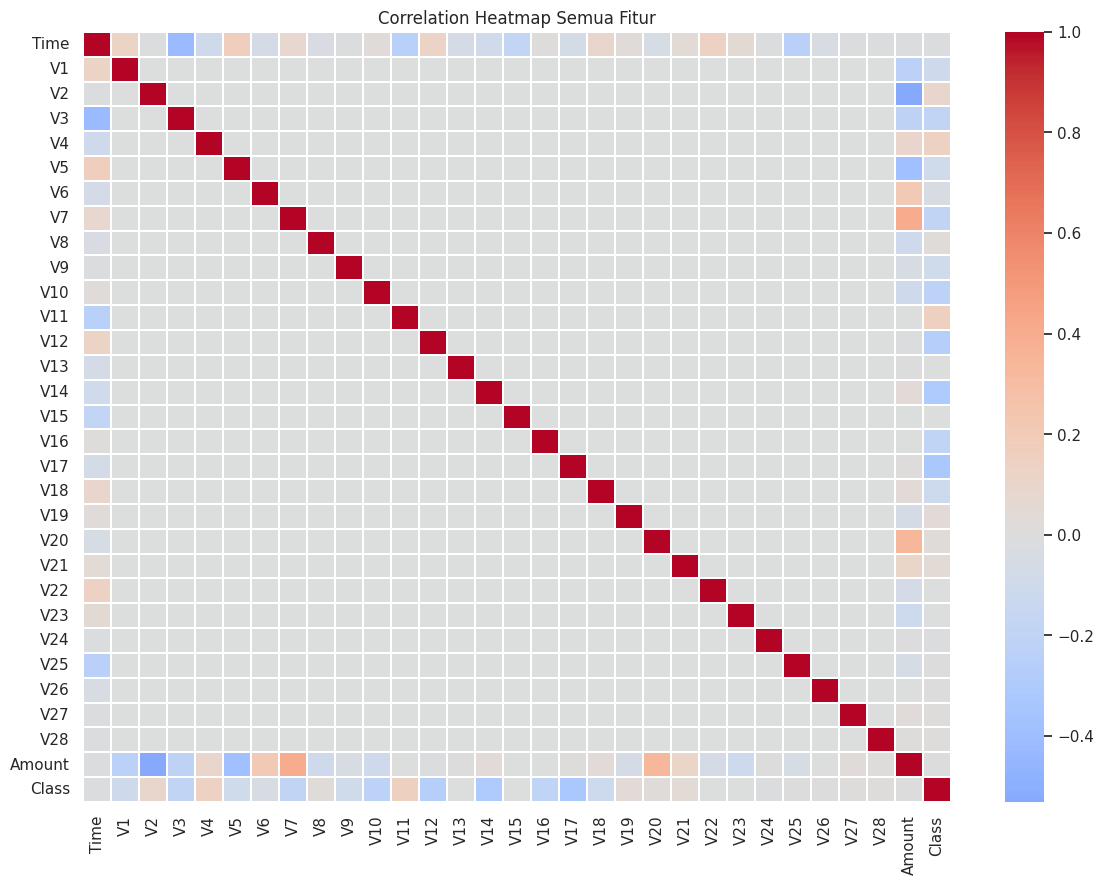

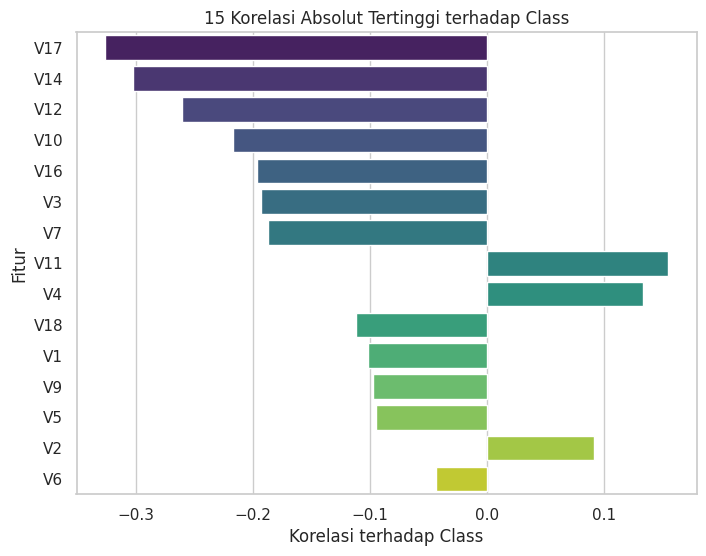

,corr_with_class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


In [10]:
corr = df.corr(numeric_only=True)
class_corr = corr["Class"].drop("Class").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Correlation Heatmap Semua Fitur")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=class_corr.head(15).values,
    y=class_corr.head(15).index,
    palette="viridis",
)
plt.title("15 Korelasi Absolut Tertinggi terhadap Class")
plt.xlabel("Korelasi terhadap Class")
plt.ylabel("Fitur")
plt.show()

display(class_corr.head(15).to_frame("corr_with_class"))



**Interpretasi:** korelasi linear terhadap `Class` dapat membantu membaca sinyal
awal, tetapi fraud detection sering membutuhkan model non-linear karena pola
fraud muncul dari kombinasi fitur, bukan dari satu fitur tunggal.



## 3. Preprocessing

Fitur `V1` sampai `V28` tidak di-scaling ulang karena sudah merupakan hasil PCA.
Scaling hanya diterapkan pada `Time` dan `Amount`. Scaler di-fit hanya pada data
training untuk menghindari data leakage.

Selain train-test split 80:20, data training dipecah lagi menjadi train dan
validation. Validation dipakai untuk threshold tuning agar test set tetap
menjadi evaluasi akhir yang lebih objektif.



In [11]:
X = df.drop(columns="Class")
y = df["Class"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

scaler = RobustScaler()
scale_cols = ["Time", "Amount"]

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Ukuran train     :", X_train_scaled.shape)
print("Ukuran validation:", X_val_scaled.shape)
print("Ukuran test      :", X_test_scaled.shape)
print("\nDistribusi kelas train:")
print(y_train.value_counts().sort_index())
print("\nDistribusi kelas validation:")
print(y_val.value_counts().sort_index())
print("\nDistribusi kelas test:")
print(y_test.value_counts().sort_index())



Ukuran train     : (170883, 30)
Ukuran validation: (56962, 30)
Ukuran test      : (56962, 30)

Distribusi kelas train:
Class
0    170588
1       295
Name: count, dtype: int64

Distribusi kelas validation:
Class
0    56863
1       99
Name: count, dtype: int64

Distribusi kelas test:
Class
0    56864
1       98
Name: count, dtype: int64


**Interpretasi:** stratified split menjaga proporsi kelas fraud dan normal pada
train, validation, dan test. Ini penting karena jumlah fraud sangat sedikit.



## 4. Handling imbalanced data

Untuk XGBoost, imbalance ditangani dengan `scale_pos_weight`, yaitu:

`jumlah kelas normal pada training / jumlah kelas fraud pada training`



In [12]:
train_class_counts = y_train.value_counts().sort_index()
negative_count = train_class_counts.loc[0]
positive_count = train_class_counts.loc[1]
scale_pos_weight = negative_count / positive_count

print(f"Normal pada training: {negative_count:,}")
print(f"Fraud pada training : {positive_count:,}")
print(f"scale_pos_weight    : {scale_pos_weight:.4f}")



Normal pada training: 170,588
Fraud pada training : 295
scale_pos_weight    : 578.2644


**Interpretasi:** bobot ini memberi penalti lebih besar pada kesalahan terhadap
kelas fraud, sehingga model tidak terlalu condong ke kelas normal.



## 5. Fungsi evaluasi

Fungsi berikut dipakai untuk menghitung metrik utama. `F2-score` ditambahkan
untuk threshold tuning karena F2 memberi bobot lebih besar pada recall.



In [13]:
def evaluate_at_threshold(y_true, y_proba, threshold=0.5):
    """Return metrics and confusion-matrix components for one threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "threshold": threshold,
        "precision_fraud": precision_score(y_true, y_pred, zero_division=0),
        "recall_fraud": recall_score(y_true, y_pred, zero_division=0),
        "f1_fraud": f1_score(y_true, y_pred, zero_division=0),
        "f2_fraud": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def evaluate_probability_model(name, y_true, y_proba, threshold=0.5):
    """Print classification metrics for a probability-based binary classifier."""
    metrics = evaluate_at_threshold(y_true, y_proba, threshold)
    y_pred = (y_proba >= threshold).astype(int)

    print(f"Model: {name}")
    print(f"Threshold: {threshold}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    print(f"ROC-AUC : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_true, y_proba):.4f}")

    return metrics


def plot_confusion_matrix(y_true, y_proba, threshold, title):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred Normal", "Pred Fraud"],
        yticklabels=["Actual Normal", "Actual Fraud"],
    )
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()



## 6. Modeling dengan XGBoost

Model utama menggunakan `XGBClassifier` dengan objective `binary:logistic`,
`eval_metric="aucpr"`, dan `scale_pos_weight` dari data training.



Model: XGBoost default threshold
Threshold: 0.5

Confusion matrix:
[[56826    38]
 [   14    84]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9993    0.9995     56864
           1     0.6885    0.8571    0.7636        98

    accuracy                         0.9991     56962
   macro avg     0.8441    0.9282    0.8816     56962
weighted avg     0.9992    0.9991    0.9991     56962

ROC-AUC : 0.9730
PR-AUC  : 0.8481


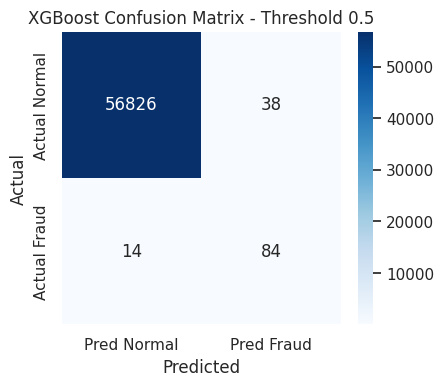

In [14]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_lambda=1.0,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model.fit(X_train_scaled, y_train)

xgb_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_default_metrics = evaluate_probability_model(
    "XGBoost default threshold",
    y_test,
    xgb_test_proba,
    threshold=0.5,
)
plot_confusion_matrix(
    y_test,
    xgb_test_proba,
    threshold=0.5,
    title="XGBoost Confusion Matrix - Threshold 0.5",
)



**Interpretasi:** evaluasi threshold 0.5 menjadi baseline model XGBoost. Pada
fraud detection, fokus utama adalah berapa banyak fraud yang berhasil ditemukan
(`recall`) dan seberapa banyak alert fraud yang benar (`precision`).



## 7. Threshold tuning

Threshold diuji pada validation set, bukan test set, untuk mengurangi risiko
data leakage dalam pemilihan threshold. Setelah threshold dipilih, performa
akhir dievaluasi pada test set.



In [15]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = pd.DataFrame(
    [evaluate_at_threshold(y_val, xgb_val_proba, threshold) for threshold in thresholds]
)

display(threshold_results)

# Pilih threshold dengan F2-score tertinggi karena F2 lebih memprioritaskan recall.
best_threshold_row = threshold_results.sort_values(
    ["f2_fraud", "recall_fraud", "precision_fraud"],
    ascending=False,
).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print("Threshold terbaik berdasarkan validation F2-score:")
display(best_threshold_row.to_frame("value"))



,threshold,precision_fraud,recall_fraud,f1_fraud,f2_fraud,tn,fp,fn,tp
0,0.1,0.288660,0.848485,0.430769,0.611354,56656,207,15,84
1,0.2,0.457627,0.818182,0.586957,0.706806,56767,96,18,81
2,0.3,0.571429,0.808081,0.669456,0.746269,56803,60,19,80
3,0.4,0.666667,0.787879,0.722222,0.760234,56824,39,21,78
4,0.5,0.715596,0.787879,0.750000,0.772277,56832,31,21,78
5,0.6,0.764706,0.787879,0.776119,0.783133,56839,24,21,78
6,0.7,0.804124,0.787879,0.795918,0.791075,56844,19,21,78
7,0.8,0.827957,0.777778,0.802083,0.787321,56847,16,22,77
8,0.9,0.882353,0.757576,0.815217,0.779626,56853,10,24,75


Threshold terbaik berdasarkan validation F2-score:


,value
threshold,0.700000
precision_fraud,0.804124
recall_fraud,0.787879
f1_fraud,0.795918
f2_fraud,0.791075
tn,56844.000000
fp,19.000000
fn,21.000000
tp,78.000000


Model: XGBoost selected threshold
Threshold: 0.7

Confusion matrix:
[[56837    27]
 [   16    82]]

Classification report:
              precision    recall  f1-score   support

           0     0.9997    0.9995    0.9996     56864
           1     0.7523    0.8367    0.7923        98

    accuracy                         0.9992     56962
   macro avg     0.8760    0.9181    0.8959     56962
weighted avg     0.9993    0.9992    0.9993     56962

ROC-AUC : 0.9730
PR-AUC  : 0.8481


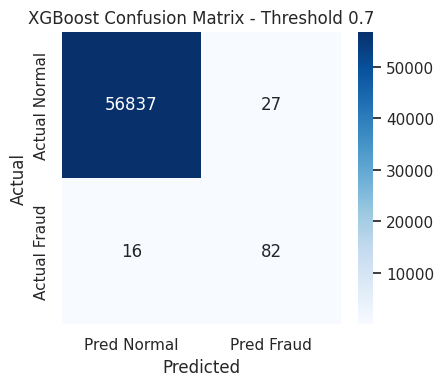

In [16]:
xgb_best_metrics = evaluate_probability_model(
    "XGBoost selected threshold",
    y_test,
    xgb_test_proba,
    threshold=best_threshold,
)
plot_confusion_matrix(
    y_test,
    xgb_test_proba,
    threshold=best_threshold,
    title=f"XGBoost Confusion Matrix - Threshold {best_threshold}",
)



**Interpretasi trade-off:** threshold rendah biasanya meningkatkan recall
fraud, tetapi menambah false positive. Threshold tinggi biasanya menurunkan
false positive dan meningkatkan precision, tetapi bisa melewatkan lebih banyak
fraud. Pada kasus fraud detection, threshold operasional sebaiknya dipilih
berdasarkan kapasitas tim review dan toleransi risiko fraud yang lolos.



## 8. Feature importance XGBoost

Feature importance berikut berasal dari model XGBoost. Nilai tinggi berarti
fitur tersebut sering dipakai model untuk memisahkan kelas, tetapi bukan bukti
hubungan kausal.



,feature,importance
14,V14,0.376476
12,V12,0.074034
10,V10,0.070451
4,V4,0.057825
20,V20,0.037342
8,V8,0.035734
29,Amount,0.033702
19,V19,0.023838
13,V13,0.023628
17,V17,0.020466


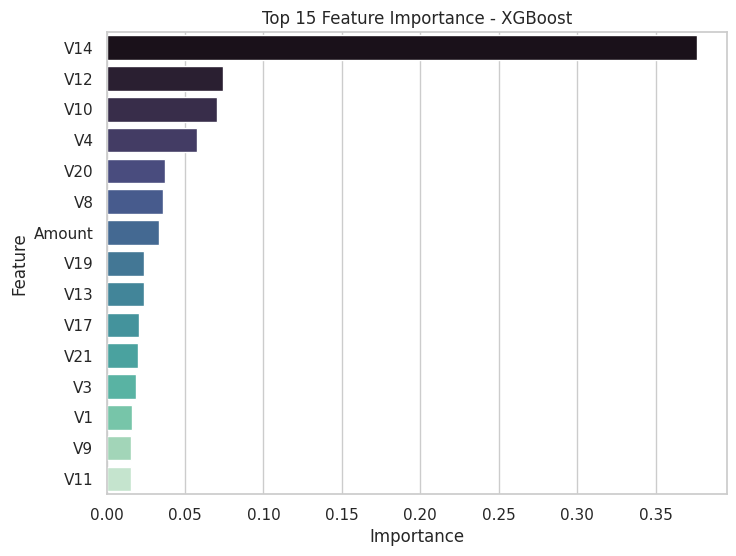

In [17]:
feature_importance = pd.DataFrame(
    {
        "feature": X_train_scaled.columns,
        "importance": xgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature",
    palette="mako",
)
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()



**Interpretasi:** fitur teratas menunjukkan sinyal paling kuat menurut model.
Karena `V1` sampai `V28` adalah hasil PCA dan sudah dianonimkan, penjelasan
bisnis langsung terbatas. Namun, ranking ini tetap berguna untuk memahami pola
teknis yang dipakai model.



### Interpretasi dengan SHAP (opsional)

SHAP memberi interpretasi kontribusi fitur terhadap prediksi. Cell ini memakai
sampel test agar waktu komputasi tetap ringan. Jika library SHAP tidak tersedia
atau tidak kompatibel dengan versi XGBoost lokal, analisis feature importance di
atas tetap dapat dipakai.



In [18]:
try:
    import shap

    shap_sample = X_test_scaled.sample(
        n=min(1000, len(X_test_scaled)),
        random_state=RANDOM_STATE,
    )
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values,
        shap_sample,
        max_display=15,
        show=True,
    )
except Exception as exc:
    print("SHAP tidak dapat dijalankan di environment ini.")
    print("Alasan:", repr(exc))



SHAP tidak dapat dijalankan di environment ini.
Alasan: ValueError("could not convert string to float: '[5E-1]'")


## 9. Baseline: Logistic Regression

Sebagai pembanding sederhana, digunakan Logistic Regression dengan
`class_weight="balanced"`. Model ini membantu melihat apakah XGBoost memberi
nilai tambah pada data tabular imbalance.



Model: Logistic Regression balanced
Threshold: 0.5

Confusion matrix:
[[55492  1372]
 [    8    90]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9759    0.9877     56864
           1     0.0616    0.9184    0.1154        98

    accuracy                         0.9758     56962
   macro avg     0.5307    0.9471    0.5516     56962
weighted avg     0.9982    0.9758    0.9862     56962

ROC-AUC : 0.9726
PR-AUC  : 0.7209


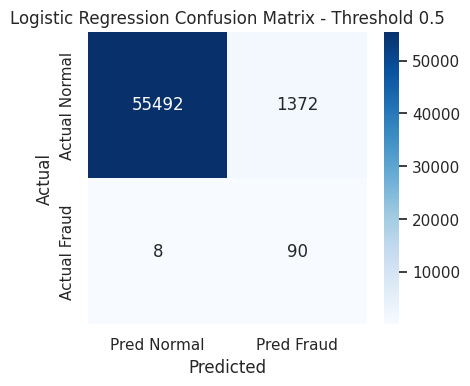

In [19]:
baseline_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
    random_state=RANDOM_STATE,
)

baseline_lr.fit(X_train_scaled, y_train)
lr_test_proba = baseline_lr.predict_proba(X_test_scaled)[:, 1]

lr_metrics = evaluate_probability_model(
    "Logistic Regression balanced",
    y_test,
    lr_test_proba,
    threshold=0.5,
)
plot_confusion_matrix(
    y_test,
    lr_test_proba,
    threshold=0.5,
    title="Logistic Regression Confusion Matrix - Threshold 0.5",
)



In [20]:
comparison = pd.DataFrame(
    [
        {
            "model": "Logistic Regression balanced",
            "threshold": 0.5,
            "precision_fraud": lr_metrics["precision_fraud"],
            "recall_fraud": lr_metrics["recall_fraud"],
            "f1_fraud": lr_metrics["f1_fraud"],
            "pr_auc": average_precision_score(y_test, lr_test_proba),
        },
        {
            "model": "XGBoost default threshold",
            "threshold": 0.5,
            "precision_fraud": xgb_default_metrics["precision_fraud"],
            "recall_fraud": xgb_default_metrics["recall_fraud"],
            "f1_fraud": xgb_default_metrics["f1_fraud"],
            "pr_auc": average_precision_score(y_test, xgb_test_proba),
        },
        {
            "model": "XGBoost selected threshold",
            "threshold": best_threshold,
            "precision_fraud": xgb_best_metrics["precision_fraud"],
            "recall_fraud": xgb_best_metrics["recall_fraud"],
            "f1_fraud": xgb_best_metrics["f1_fraud"],
            "pr_auc": average_precision_score(y_test, xgb_test_proba),
        },
    ]
)

display(comparison.sort_values("pr_auc", ascending=False))



,model,threshold,precision_fraud,recall_fraud,f1_fraud,pr_auc
1,XGBoost default threshold,0.5,0.688525,0.857143,0.763636,0.848096
2,XGBoost selected threshold,0.7,0.752294,0.836735,0.792271,0.848096
0,Logistic Regression balanced,0.5,0.061560,0.918367,0.115385,0.720881


**Interpretasi:** Logistic Regression sering menghasilkan recall tinggi, tetapi
dengan false positive jauh lebih banyak. XGBoost biasanya lebih baik untuk data
tabular non-linear karena mampu menangkap interaksi antar fitur PCA.



## 10. Ringkasan akhir

Cell berikut mencetak ringkasan utama agar hasil project mudah dibaca ulang
setelah notebook dijalankan.



In [21]:
print("Ringkasan dataset")
print(f"- Total data: {len(df):,} transaksi")
print(f"- Normal: {normal_count:,} ({class_percent.loc[0]:.4f}%)")
print(f"- Fraud : {fraud_count:,} ({class_percent.loc[1]:.4f}%)")
print(f"- Missing value total: {int(df.isna().sum().sum())}")
print(f"- Duplikasi: {int(df.duplicated().sum())}")

print("\nAlasan XGBoost")
print("- Cocok untuk data tabular numerik.")
print("- Mampu menangkap hubungan non-linear antar fitur.")
print("- Mendukung handling imbalance melalui scale_pos_weight.")

print("\nPreprocessing")
print("- X dan y dipisah dari kolom Class.")
print("- Time dan Amount di-scale dengan RobustScaler.")
print("- V1 sampai V28 tidak di-scale ulang karena merupakan fitur PCA.")
print("- Split dilakukan secara stratified.")
print("- Threshold dipilih menggunakan validation set.")

print("\nHasil XGBoost pada test set")
print(f"- Threshold default 0.5 recall fraud: {xgb_default_metrics['recall_fraud']:.4f}")
print(f"- Threshold default 0.5 precision fraud: {xgb_default_metrics['precision_fraud']:.4f}")
print(f"- Threshold terpilih: {best_threshold}")
print(f"- Recall fraud threshold terpilih: {xgb_best_metrics['recall_fraud']:.4f}")
print(f"- Precision fraud threshold terpilih: {xgb_best_metrics['precision_fraud']:.4f}")
print(f"- F1 fraud threshold terpilih: {xgb_best_metrics['f1_fraud']:.4f}")
print(f"- ROC-AUC: {roc_auc_score(y_test, xgb_test_proba):.4f}")
print(f"- PR-AUC : {average_precision_score(y_test, xgb_test_proba):.4f}")

print("\nSaran pengembangan")
print("- Validasi dengan cross-validation berbasis stratified fold.")
print("- Tuning hyperparameter XGBoost dengan fokus PR-AUC dan recall fraud.")
print("- Coba threshold sesuai kapasitas tim investigasi fraud.")
print("- Evaluasi cost-sensitive learning bila biaya false negative dan false positive diketahui.")
print("- Uji monitoring data drift untuk skenario production.")


Ringkasan dataset
- Total data: 284,807 transaksi
- Normal: 284,315 (99.8273%)
- Fraud : 492 (0.1727%)
- Missing value total: 0
- Duplikasi: 1081

Alasan XGBoost
- Cocok untuk data tabular numerik.
- Mampu menangkap hubungan non-linear antar fitur.
- Mendukung handling imbalance melalui scale_pos_weight.

Preprocessing
- X dan y dipisah dari kolom Class.
- Time dan Amount di-scale dengan RobustScaler.
- V1 sampai V28 tidak di-scale ulang karena merupakan fitur PCA.
- Split dilakukan secara stratified.
- Threshold dipilih menggunakan validation set.

Hasil XGBoost pada test set
- Threshold default 0.5 recall fraud: 0.8571
- Threshold default 0.5 precision fraud: 0.6885
- Threshold terpilih: 0.7
- Recall fraud threshold terpilih: 0.8367
- Precision fraud threshold terpilih: 0.7523
- F1 fraud threshold terpilih: 0.7923
- ROC-AUC: 0.9730
- PR-AUC : 0.8481

Saran pengembangan
- Validasi dengan cross-validation berbasis stratified fold.
- Tuning hyperparameter XGBoost dengan fokus PR-AUC dan